# LightFM Hybrid Factorization

## Роль notebook

Этот notebook нужен как bridge-step между `ALS` и `Neural CF`.
Здесь мы не меняем домен и не уходим сразу в нейросети.
Главная идея: показать, как latent factor модель начинает использовать item-features.

## План

- взять ту же базовую offline-постановку, что и в `ALS`;
- собрать простые item-features из `MovieLens`, начиная с `genres`;
- обучить модель `LightFM` в hybrid-режиме;
- получить top-K рекомендации;
- сравнить результат минимум с `ALS` в максимально близких условиях.

## Validation checklist

- split и candidate universe согласованы с `ALS`;
- роль item-features объяснена явно, без библиотечной магии;
- различие между pure collaborative и hybrid factorization видно на одном и том же сценарии;
- notebook использует реальную библиотеку `lightfm`, а не самодельную замену.


## Требование к окружению

Этот notebook должен использовать реальную библиотеку `lightfm`.
Если она не установлена, выполнение нужно остановить и сначала установить зависимость, например `pip install lightfm-next` для Python 3.12


## Интуиция

В `ALS` каждый объект описывался только через взаимодействия пользователей.

Здесь появляется новый слой:

- у объекта есть не только `item_id`;
- у него есть признаки, например жанры;
- модель может учиться не только на совместных просмотрах, но и на этих признаках.

Именно это делает hybrid factorization полезным мостом между:

- `content-based` логикой;
- latent factors;
- следующими, более сложными моделями вроде `Neural CF`.


In [1]:
import os

os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"

from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

import warnings
warnings.filterwarnings("ignore", message="LightFM was compiled without OpenMP support.*", category=UserWarning,)


def find_project_root(start_path: Path) -> Path:
    for candidate in [start_path, *start_path.parents]:
        if (candidate / "src" / "recsys_basics").exists():
            return candidate
    raise FileNotFoundError("Не удалось найти корень проекта с папкой src/recsys_basics")


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")
plt.style.use("ggplot")

print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"SRC_DIR: {SRC_DIR}")


PROJECT_ROOT: /Users/bobrsubr/PycharmProjects/_researches/recommender-systems-from-zero
SRC_DIR: /Users/bobrsubr/PycharmProjects/_researches/recommender-systems-from-zero/src


In [2]:
try:
    from lightfm import LightFM
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError(
        "Библиотека `lightfm` не установлена. Установите её в окружение проекта (`pip install lightfm` или `pip install -r requirements.txt`) и перезапустите notebook."
    ) from exc

from recsys_basics.advanced.als import ImplicitALSRecommender
from recsys_basics.advanced.lightfm import (
    LightFMHybridRecommender,
    build_item_genre_feature_map,
)
from recsys_basics.basic.popularity import (
    PopularityRecommender,
    build_seen_items_map,
    filter_positive_explicit_feedback,
)
from recsys_basics.data import build_explicit_interactions, get_movielens_data_dir, load_movielens_frames
from recsys_basics.metrics import evaluate_ranking_metrics
from recsys_basics.split import assert_no_user_time_leakage, leave_last_two_out_split

DATA_DIR = get_movielens_data_dir()
MIN_RATING = 4.0
TOP_K = 10

frames = load_movielens_frames(DATA_DIR)
interactions_df = build_explicit_interactions(frames.ratings)
movies_df = frames.movies.rename(columns={"movieId": "item_id"}).copy()

print(f"Interactions loaded: {len(interactions_df):,}")
print(f"Movies loaded: {len(movies_df):,}")


Interactions loaded: 100,836
Movies loaded: 9,742


## Базовая постановка остаётся той же

Чтобы сравнение было честным, оставляем ту же логику, что и в `ALS`:

- положительный сигнал: `rating >= 4.0`;
- тот же `train/validation/test` split;
- те же top-K метрики;
- тот же candidate universe.

Здесь `train / validation / test` делятся не по фиксированным процентам, а по временной логике на пользователя.
Поэтому `validation` и `test` получаются маленькими по числу строк, но это нормально: их задача не занять условные `10%` датасета, а дать по одному честному отложенному примеру на каждого пользователя.

Меняется только одно:
к `item_id` добавляются признаки объектов.


In [3]:
positive_df = filter_positive_explicit_feedback(interactions_df, min_rating=MIN_RATING)
split_result = leave_last_two_out_split(positive_df, min_user_interactions=3)
train_df = split_result.train
val_df = split_result.validation
test_df = split_result.test

assert_no_user_time_leakage(train_df, val_df)
assert_no_user_time_leakage(pd.concat([train_df, val_df], ignore_index=True), test_df)

split_summary = pd.DataFrame(
    {
        "metric": [
            "train_rows",
            "validation_rows",
            "test_rows",
            "train_users",
            "validation_users",
            "test_users",
            "train_items",
            "validation_items",
            "test_items",
        ],
        "value": [
            len(train_df),
            len(val_df),
            len(test_df),
            train_df['user_id'].nunique(),
            val_df['user_id'].nunique(),
            test_df['user_id'].nunique(),
            train_df['item_id'].nunique(),
            val_df['item_id'].nunique(),
            test_df['item_id'].nunique(),
        ],
    }
)

display(split_summary)


,metric,value
0,train_rows,47363
1,validation_rows,608
2,test_rows,608
3,train_users,608
4,validation_users,608
5,test_users,608
6,train_items,6227
7,validation_items,488
8,test_items,503


## Собираем item-features из жанров

Для первого feature-aware шага этого достаточно:

- признаки понятны новичку;
- они уже лежат в `movies.csv`;
- можно сравнить hybrid factorization с `ALS`, не меняя домен.


In [4]:
item_feature_map = build_item_genre_feature_map(movies_df)

feature_preview = pd.DataFrame(
    [
        {
            'item_id': item_id,
            'title': movies_df.loc[movies_df['item_id'] == item_id, 'title'].iloc[0],
            'genre_features': item_feature_map[item_id],
        }
        for item_id in sorted(train_df['item_id'].unique().tolist())[:5]
    ]
)

all_feature_tokens = sorted({token for tokens in item_feature_map.values() for token in tokens})
print(f"Unique genre features: {len(all_feature_tokens)}")
display(feature_preview)


Unique genre features: 20


,item_id,title,genre_features
0,1,Toy Story (1995),"[adventure, animation, children, comedy, fantasy]"
1,2,Jumanji (1995),"[adventure, children, fantasy]"
2,3,Grumpier Old Men (1995),"[comedy, romance]"
3,5,Father of the Bride Part II (1995),[comedy]
4,6,Heat (1995),"[action, crime, thriller]"


## Обучаем baseline, ALS и LightFM

Сравниваем три модели:

- `popularity baseline`;
- чисто коллаборативный `ALS`;
- hybrid factorization на `LightFM`.

Так мы увидим, что именно дают item-features поверх latent factors.


In [5]:
seen_items_map = build_seen_items_map(train_df)
all_user_ids = sorted(val_df['user_id'].unique().tolist())

popularity_model = PopularityRecommender().fit(train_df)
als_model = ImplicitALSRecommender(
    n_factors=16,
    n_iterations=8,
    regularization=0.1,
    alpha=20.0,
    random_state=42,
).fit(train_df)
lightfm_model = LightFMHybridRecommender(
    no_components=16,
    loss='warp',
    learning_rate=0.05,
    item_alpha=1e-6,
    user_alpha=1e-6,
    epochs=15,
    num_threads=1,
    random_state=42,
).fit(train_df, item_features=item_feature_map)

print(f"ALS item space: {als_model.item_factors_.shape}")
print(f"LightFM interactions: {lightfm_model.interaction_matrix_.shape}")
print(f"LightFM item features: {lightfm_model.item_feature_matrix_.shape}")
print(f"LightFM feature tokens: {len(lightfm_model.feature_to_index_)}")


  0%|          | 0/8 [00:00<?, ?it/s]

ALS item space: (6227, 16)
LightFM interactions: (608, 6227)
LightFM item features: (6227, 6247)
LightFM feature tokens: 20


## Пример рекомендаций

Сначала сделаем qualitative sanity-check и посмотрим, как меняется выдача, когда к latent factors добавляются признаки объектов.


In [6]:
popularity_recs = popularity_model.recommend_many(all_user_ids, seen_items_map=seen_items_map, k=TOP_K)
als_recs = als_model.recommend_many(all_user_ids, seen_items_map=seen_items_map, k=TOP_K)
lightfm_recs = lightfm_model.recommend_many(all_user_ids, seen_items_map=seen_items_map, k=TOP_K)

val_items_map = val_df.set_index('user_id')['item_id'].to_dict()

def hit_user_ids(recommendations: pd.DataFrame) -> list[int]:
    rec_map = recommendations.groupby('user_id')['item_id'].agg(list).to_dict()
    return [user_id for user_id, item_id in val_items_map.items() if item_id in rec_map.get(user_id, [])]


lightfm_hit_users = hit_user_ids(lightfm_recs)
sample_user_ids = lightfm_hit_users[:3] if lightfm_hit_users else all_user_ids[:3]
sample_rows = []

for user_id in sample_user_ids:
    val_item_id = int(val_items_map[user_id])
    val_title = movies_df.loc[movies_df['item_id'] == val_item_id, 'title'].iloc[0]
    for model_name, recommendations_df in [
        ('popularity', popularity_recs),
        ('als', als_recs),
        ('lightfm', lightfm_recs),
    ]:
        recommended_ids = recommendations_df.loc[
            recommendations_df['user_id'] == user_id, 'item_id'
        ].tolist()
        recommended_titles = movies_df[movies_df['item_id'].isin(recommended_ids)][['item_id', 'title']]
        sample_rows.append(
            {
                'user_id': user_id,
                'model': model_name,
                'validation_item_id': val_item_id,
                'validation_title': val_title,
                'hit_at_10': val_item_id in recommended_ids,
                'recommended_titles': recommended_titles['title'].tolist()[:5],
            }
        )

display(pd.DataFrame(sample_rows))


,user_id,model,validation_item_id,validation_title,hit_at_10,recommended_titles
0,12,popularity,1721,Titanic (1997),False,"[Braveheart (1995), Star Wars: Episode IV - A ..."
1,12,als,1721,Titanic (1997),False,"[Clueless (1995), While You Were Sleeping (199..."
2,12,lightfm,1721,Titanic (1997),True,"[Clueless (1995), Dave (1993), Sleepless in Se..."
3,26,popularity,47,Seven (a.k.a. Se7en) (1995),False,"[Usual Suspects, The (1995), Braveheart (1995)..."
4,26,als,47,Seven (a.k.a. Se7en) (1995),True,"[Seven (a.k.a. Se7en) (1995), Braveheart (1995..."
5,26,lightfm,47,Seven (a.k.a. Se7en) (1995),True,"[Seven (a.k.a. Se7en) (1995), Usual Suspects, ..."
6,35,popularity,590,Dances with Wolves (1990),False,"[Braveheart (1995), Star Wars: Episode IV - A ..."
7,35,als,590,Dances with Wolves (1990),True,"[Babe (1995), Braveheart (1995), Crimson Tide ..."
8,35,lightfm,590,Dances with Wolves (1990),True,"[Dead Man Walking (1995), Pulp Fiction (1994),..."


## Количественное сравнение

Считаем те же метрики, что и раньше, но уже на `validation`.
Так можно честно сравнить, что даёт добавление item-features поверх чисто collaborative factorization, не тратя `test` на промежуточные решения.


In [7]:
def summarize_metrics(name: str, recommendations: pd.DataFrame, k: int = TOP_K) -> dict[str, float | str]:
    metrics_df = evaluate_ranking_metrics(val_df, recommendations, k=k)
    unique_items = recommendations['item_id'].nunique() if not recommendations.empty else 0
    catalog_items = train_df['item_id'].nunique()
    summary = {'model': name}
    for column in metrics_df.columns:
        if column == 'user_id':
            continue
        summary[column] = float(metrics_df[column].mean())
    summary['catalog_coverage'] = unique_items / catalog_items if catalog_items else 0.0
    summary['unique_recommended_items'] = int(unique_items)
    return summary


metrics_summary = pd.DataFrame(
    [
        summarize_metrics('popularity', popularity_recs),
        summarize_metrics('als', als_recs),
        summarize_metrics('lightfm', lightfm_recs),
    ]
)

display(metrics_summary)


,model,precision@10,recall@10,hit_rate@10,map@10,ndcg@10,catalog_coverage,unique_recommended_items
0,popularity,0.0044,0.0444,0.0444,0.0120,0.0194,0.0098,61
1,als,0.0064,0.0641,0.0641,0.0208,0.0309,0.1200,747
2,lightfm,0.0064,0.0641,0.0641,0.0189,0.0293,0.0764,476


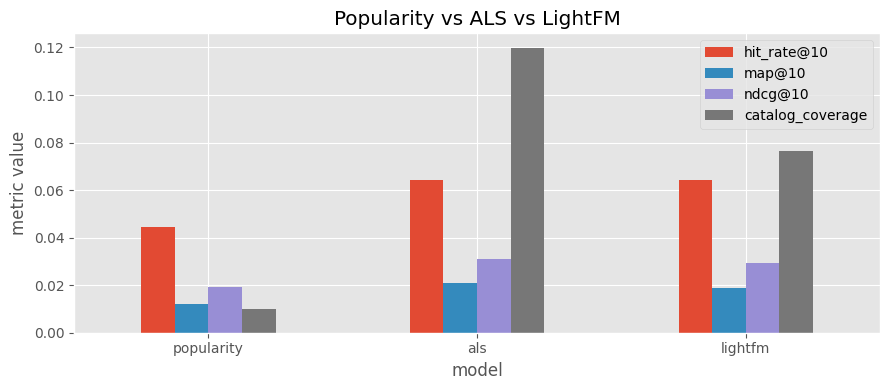

In [8]:
plot_df = metrics_summary.set_index('model')[['hit_rate@10', 'map@10', 'ndcg@10', 'catalog_coverage']]
plot_df.plot(kind='bar', figsize=(9, 4), rot=0, title='Popularity vs ALS vs LightFM')
plt.ylabel('metric value')
plt.tight_layout()
plt.show()


## Как интерпретировать результат

`LightFM` на одних `genres` уже сопоставим с `ALS` по `precision@10`, `recall@10` и `hit_rate@10`, но пока уступает по `MAP@10`, `NDCG@10` и `catalog coverage`.

Здесь важнее другой учебный вывод:

- `LightFM` сравнивается в тех же условиях, что и `ALS` и `popularity baseline`;
- мы отделяем эффект item-features от эффекта новой постановки;
- даже очень простые признаки объектов уже позволяют hybrid-модели догнать сильный коллаборативный baseline по грубым hit-метрикам;
- но для более качественного ранжирования внутри top-K одних `genres` пока недостаточно;
- `test` мы пока не используем, чтобы дальше честно улучшать признаки и модель через `validation`.

Именно поэтому после этого шага появляется хороший повод идти дальше:

- сначала посмотреть, можно ли улучшить результат через feature engineering;
- затем проверить, сколько качества можно вернуть через tuning самой модели;
- и только после этого переходить к следующему классу моделей вроде `Neural CF`.

Также нужно помнить ограничения:

- мы всё ещё работаем на учебном `MovieLens`;
- item-features здесь пока очень простые и начинаются только с `genres`;
- cold-start может стать лучше, но не исчезает полностью;
- выводы нельзя переносить на большие production-каталоги без дополнительных проверок.


## Что дальше

Следующий шаг в маршруте: [02b_lightfm_feature_engineering.ipynb](../../notebooks/advanced/02b_lightfm_feature_engineering.ipynb).

Там мы сохраним ту же модель `LightFM`, но проверим, можно ли улучшить её результат за счёт более сильных признаков объектов.
